## K-Nearest Neighbors Assignment

#### Objective:
The objective of this assignment is to implement and evaluate the K-Nearest Neighbours algorithm for classification using the given datasets
Dataset:
Need to Classify the animal type
Tasks:
1. Analyse the data using the visualizations
2. Preprocess the data by handling missing values & Outliers, if any.
3. Split the dataset into training and testing sets (80% training, 20% testing).
4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset
5. Choose an appropriate distance metric and value for K.
6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.
7. Visualize the decision boundaries of the classifier.

Interview Questions:
1. What are the key hyperparameters in KNN?
2. What distance metrics can be used in KNN?



Missing Values in Each Column:
 animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


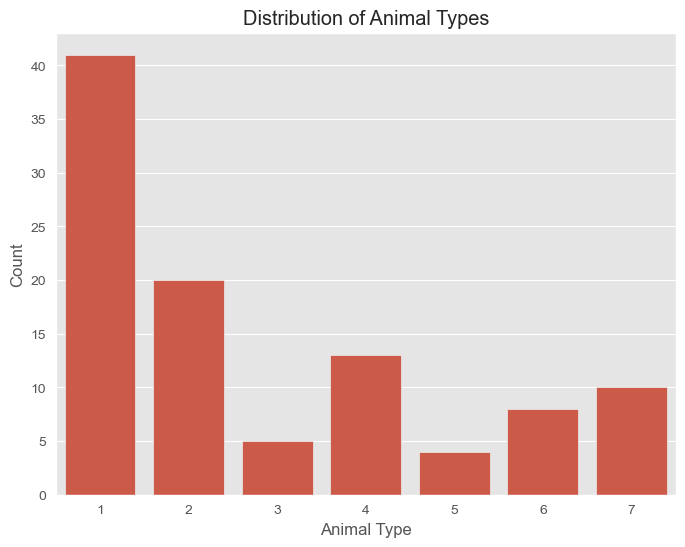

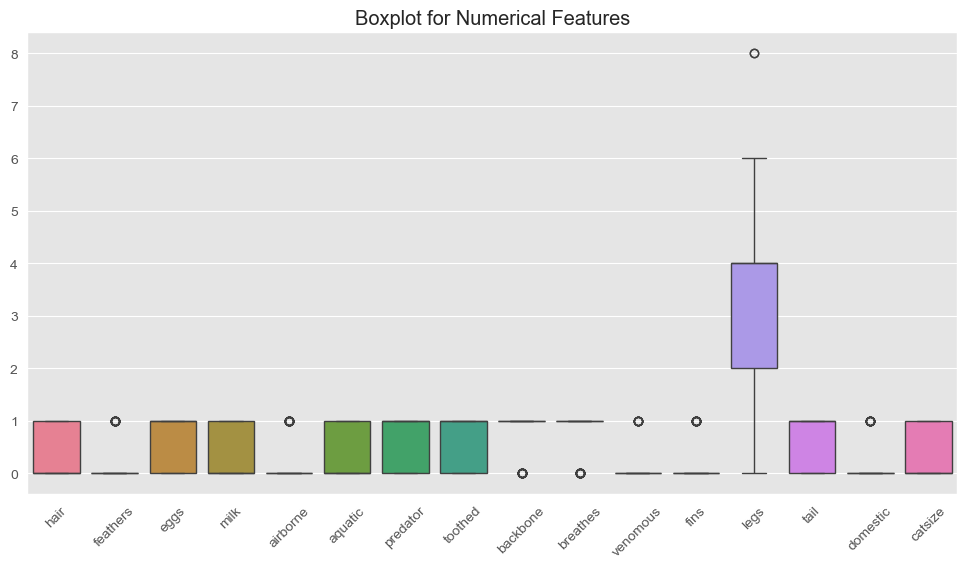

Training Set Shape: (80, 16)
Testing Set Shape: (21, 16)
Accuracy of the KNN model: 1.0

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


Confusion Matrix:
 [[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]


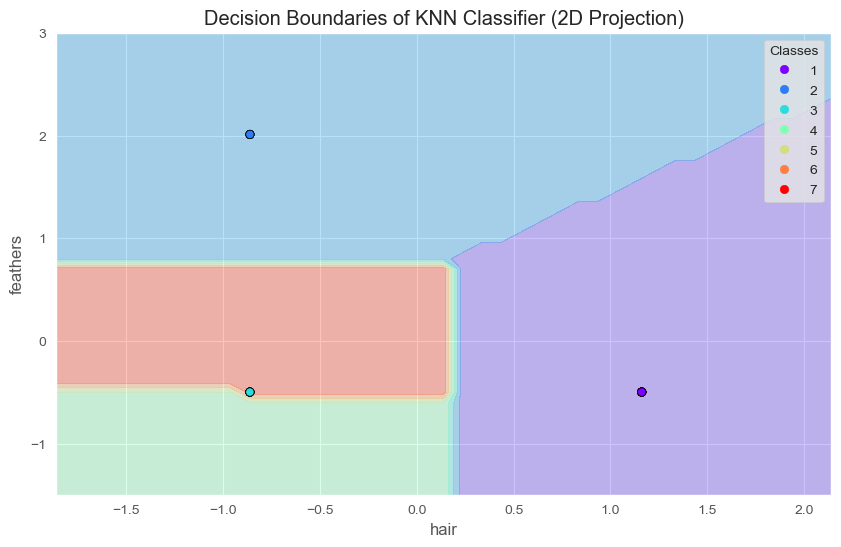

In [42]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Step 1: Load the dataset
# The dataset is a CSV file containing animal characteristics and their type.
dataset_path = 'Zoo.csv'
zoo_data = pd.read_csv(dataset_path)
zoo_data.head()

# Step 2: Analyze the dataset
# Check for missing values and visualize the class distribution
missing_values = zoo_data.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

# Visualizing the distribution of the 'type' column
plt.figure(figsize=(8, 6))
sns.countplot(data=zoo_data, x="type")
plt.title("Distribution of Animal Types")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.show()

# Step 3: Preprocess the data
# Drop the 'animal name' column as it is not relevant for classification
zoo_data_cleaned = zoo_data.drop(columns=["animal name"])

# Check for outliers using box plots for numerical features
plt.figure(figsize=(12, 6))
sns.boxplot(data=zoo_data_cleaned.drop(columns=["type"]))
plt.title("Boxplot for Numerical Features")
plt.xticks(rotation=45)
plt.show()

# Splitting the dataset into features and target variable
X = zoo_data_cleaned.drop(columns=["type"])
y = zoo_data_cleaned["type"]

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the resulting datasets
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Step 5: Implement the KNN classifier
# Initialize the KNN classifier with k=5 and Euclidean distance (p=2)
k = 5
knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)

# Train the classifier on the training data
knn.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred = knn.predict(X_test)

# Step 6: Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the KNN model:", accuracy)

# Detailed classification report
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Step 7: Visualize decision boundaries
# Use the first two features for 2D visualization
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# Re-train the KNN classifier on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
knn_2d.fit(X_train_2d, y_train)

# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model, feature_names):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict the labels for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='rainbow')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='rainbow')
    plt.title("Decision Boundaries of KNN Classifier (2D Projection)")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

# Plot decision boundaries for the test data
plot_decision_boundaries(X_test_2d, y_test, knn_2d, feature_names=X.columns[:2])

# Step 8: Answering the interview questions
# 1. What are the key hyperparameters in KNN?
#    The key hyperparameters in KNN are:
#    - The number of neighbors (k): Determines the number of nearest neighbors to consider for classification.
#    - The distance metric: Defines how the distance between points is calculated (e.g., Euclidean, Manhattan, Minkowski).
#    - Weighting: Specifies whether all neighbors contribute equally or are weighted based on their distance.

# 2. What distance metrics can be used in KNN?
#    Common distance metrics used in KNN include:
#    - Euclidean Distance: The straight-line distance between two points.
#    - Manhattan Distance: The sum of the absolute differences between the coordinates of two points.
#    - Minkowski Distance: A generalized distance metric that includes both Euclidean and Manhattan as special cases.
#    - Hamming Distance: Used for categorical variables to count the number of differing elements.
#    - Cosine Similarity: Measures the cosine of the angle between two non-zero vectors (used in some cases for text or high-dimensional data).
